In [4]:
# ===============================
# Mutual Fund Analytics - EDA
# ===============================

%pip install pandas numpy matplotlib seaborn plotly -q

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from pathlib import Path

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Plot style
sns.set_style("whitegrid")

print("Libraries imported successfully.")


[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Libraries imported successfully.


In [5]:
from pathlib import Path

# Project root
BASE_DIR = Path.cwd().parent

# Load datasets
fund_master = pd.read_csv(BASE_DIR / "data" / "processed" / "fund_master.csv")
nav_history = pd.read_csv(BASE_DIR / "data" / "processed" / "nav_history.csv")
investor_transactions = pd.read_csv(BASE_DIR / "data" / "processed" / "investor_transactions.csv")
scheme_performance = pd.read_csv(BASE_DIR / "data" / "processed" / "scheme_performance.csv")
aum_history = pd.read_csv(BASE_DIR / "data" / "processed" / "aum_history.csv")
sip_data = pd.read_csv(BASE_DIR / "data" / "processed" / "sip_data.csv")

print("All datasets loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: 'c:\\Users\\saisr\\OneDrive\\Desktop\\BlueStock Internship\\Mutual_Fund_Analytics\\data\\processed\\fund_master.csv'

In [6]:
from pathlib import Path

BASE_DIR = Path.cwd().parent

print("Current Notebook Path:", Path.cwd())
print("\nProcessed Folder Files:\n")

processed_path = BASE_DIR / "data" / "processed"

for file in processed_path.glob("*"):
    print(file.name)
    

Current Notebook Path: c:\Users\saisr\OneDrive\Desktop\BlueStock Internship\Mutual_Fund_Analytics\notebooks

Processed Folder Files:

01_fund_master.csv
02_nav_history_cleaned.csv
03_aum_by_fund_house.csv
04_monthly_sip_inflows.csv
05_category_inflows.csv
06_industry_folio_count.csv
07_scheme_performance_cleaned.csv
08_investor_transactions_cleaned.csv
09_portfolio_holdings.csv
10_benchmark_indices.csv
Axis_Bluechip.csv
ICICI_Bluechip.csv
Kotak_Bluechip.csv
live_nav_125497.csv
Nippon_Large_Cap.csv
SBI_Bluechip.csv


In [7]:
from pathlib import Path

BASE_DIR = Path.cwd().parent
PROCESSED_DIR = BASE_DIR / "data" / "processed"

fund_master = pd.read_csv(PROCESSED_DIR / "01_fund_master.csv")
nav_history = pd.read_csv(PROCESSED_DIR / "02_nav_history_cleaned.csv")
aum_by_fund_house = pd.read_csv(PROCESSED_DIR / "03_aum_by_fund_house.csv")
monthly_sip_inflows = pd.read_csv(PROCESSED_DIR / "04_monthly_sip_inflows.csv")
category_inflows = pd.read_csv(PROCESSED_DIR / "05_category_inflows.csv")
industry_folio_count = pd.read_csv(PROCESSED_DIR / "06_industry_folio_count.csv")
scheme_performance = pd.read_csv(PROCESSED_DIR / "07_scheme_performance_cleaned.csv")
investor_transactions = pd.read_csv(PROCESSED_DIR / "08_investor_transactions_cleaned.csv")
portfolio_holdings = pd.read_csv(PROCESSED_DIR / "09_portfolio_holdings.csv")
benchmark_indices = pd.read_csv(PROCESSED_DIR / "10_benchmark_indices.csv")

print("All 10 datasets loaded successfully.")

All 10 datasets loaded successfully.


In [8]:
datasets = {
    "Fund Master": fund_master,
    "NAV History": nav_history,
    "AUM by Fund House": aum_by_fund_house,
    "Monthly SIP Inflows": monthly_sip_inflows,
    "Category Inflows": category_inflows,
    "Industry Folio Count": industry_folio_count,
    "Scheme Performance": scheme_performance,
    "Investor Transactions": investor_transactions,
    "Portfolio Holdings": portfolio_holdings,
    "Benchmark Indices": benchmark_indices
}

for name, df in datasets.items():
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns")
    

Fund Master: 40 rows, 15 columns
NAV History: 46000 rows, 3 columns
AUM by Fund House: 90 rows, 5 columns
Monthly SIP Inflows: 48 rows, 6 columns
Category Inflows: 144 rows, 3 columns
Industry Folio Count: 21 rows, 6 columns
Scheme Performance: 40 rows, 20 columns
Investor Transactions: 32778 rows, 13 columns
Portfolio Holdings: 322 rows, 8 columns
Benchmark Indices: 8050 rows, 3 columns


In [9]:
# Display basic information about each dataset

for name, df in datasets.items():
    print("=" * 60)
    print(name)
    print("=" * 60)
    display(df.head())
    print("\n")

Fund Master


,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02




NAV History


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639




AUM by Fund House


...

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending




Portfolio Holdings


,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31




Benchmark Indices


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


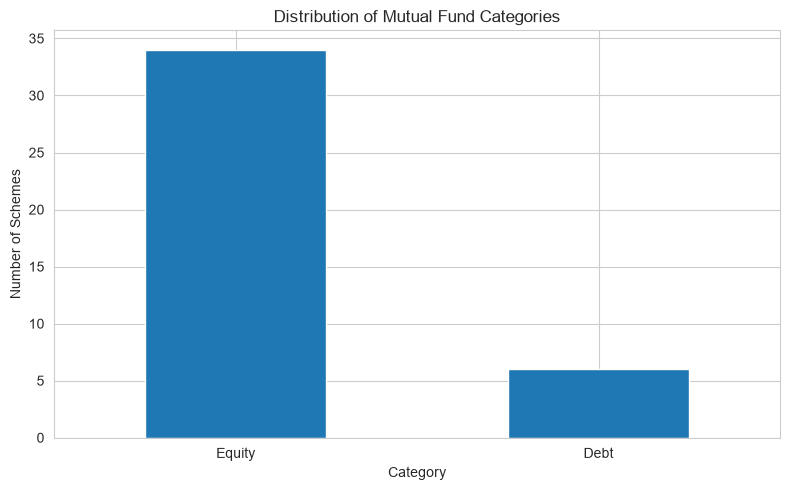

In [10]:
import matplotlib.pyplot as plt

# Count schemes in each category
category_counts = fund_master["category"].value_counts()

plt.figure(figsize=(8,5))
category_counts.plot(kind="bar")

plt.title("Distribution of Mutual Fund Categories")
plt.xlabel("Category")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [11]:
# Top 10 Fund Houses by Total AUM

top_aum = (
    aum_by_fund_house
    .groupby("fund_house")["aum_cr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_aum.plot(kind="bar")

plt.title("Top 10 Fund Houses by Total AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Crores)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

KeyError: 'Column not found: aum_cr'

In [12]:
print(aum_by_fund_house.columns.tolist())

['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes']


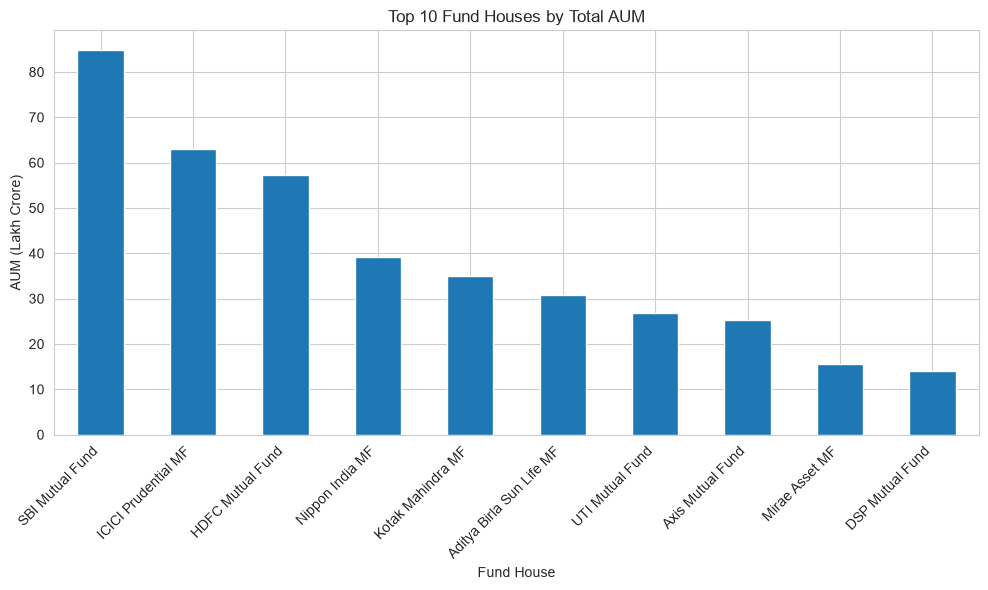

In [13]:
# Top 10 Fund Houses by Total AUM

top_aum = (
    aum_by_fund_house
    .groupby("fund_house")["aum_lakh_crore"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 6))
top_aum.plot(kind="bar")

plt.title("Top 10 Fund Houses by Total AUM")
plt.xlabel("Fund House")
plt.ylabel("AUM (Lakh Crore)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

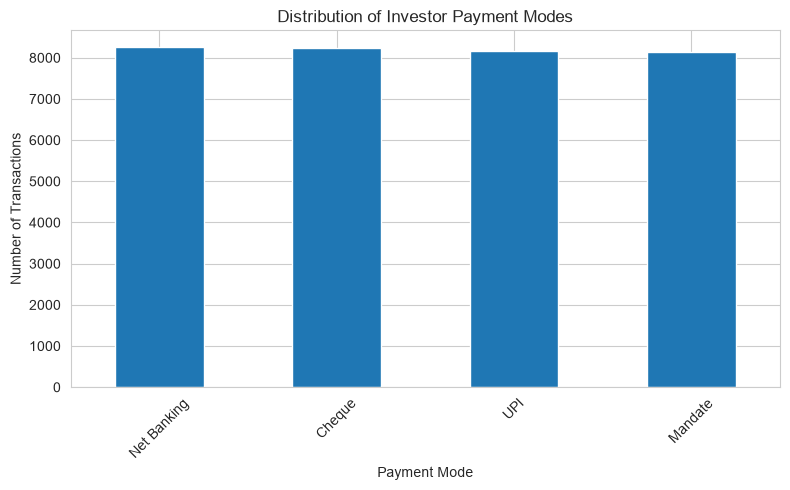

In [14]:
# Distribution of Investor Payment Modes

payment_counts = investor_transactions["payment_mode"].value_counts()

plt.figure(figsize=(8,5))
payment_counts.plot(kind="bar")

plt.title("Distribution of Investor Payment Modes")
plt.xlabel("Payment Mode")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

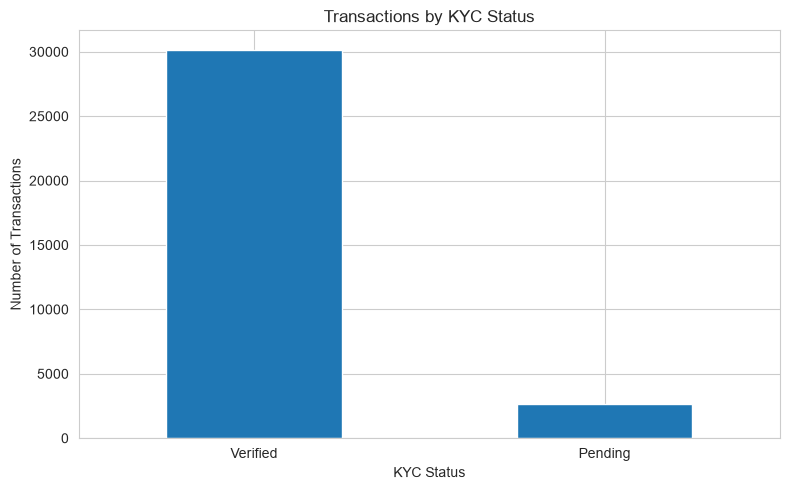

In [15]:
# Distribution of Transactions by KYC Status

kyc_counts = investor_transactions["kyc_status"].value_counts()

plt.figure(figsize=(8, 5))
kyc_counts.plot(kind="bar")

plt.title("Transactions by KYC Status")
plt.xlabel("KYC Status")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [16]:
# Top 10 States by Number of Transactions

state_counts = (
    investor_transactions["investor_state"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
state_counts.plot(kind="bar")

plt.title("Top 10 States by Number of Transactions")
plt.xlabel("State")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

KeyError: 'investor_state'

In [17]:
print(investor_transactions.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status']


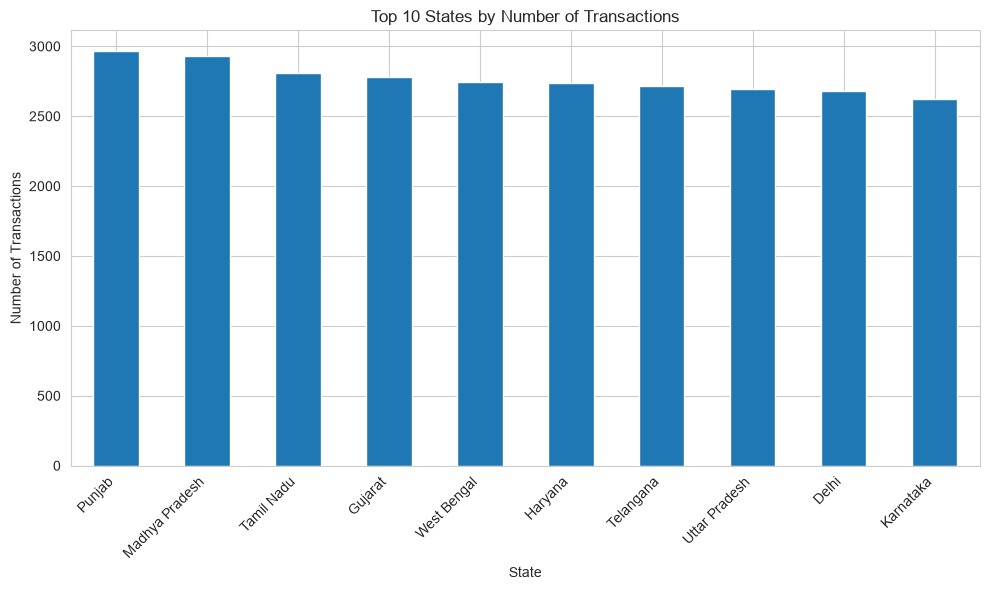

In [18]:
# Top 10 States by Number of Transactions

state_counts = (
    investor_transactions["state"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
state_counts.plot(kind="bar")

plt.title("Top 10 States by Number of Transactions")
plt.xlabel("State")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

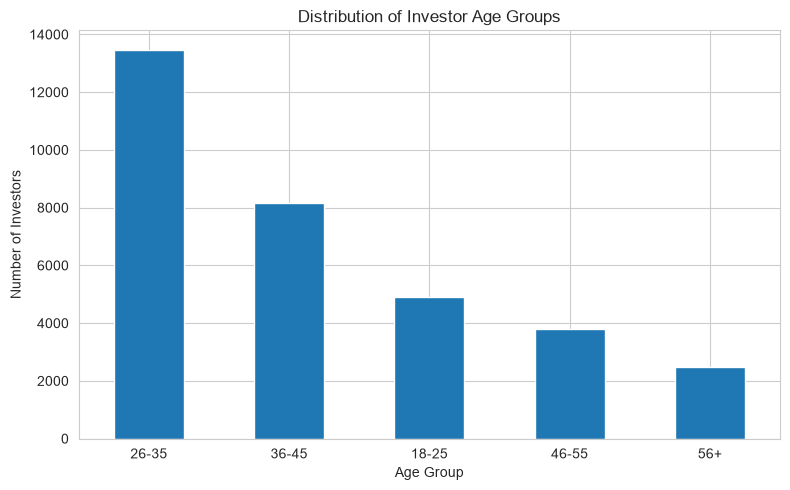

In [19]:
# Distribution of Investor Age Groups

age_counts = investor_transactions["age_group"].value_counts()

plt.figure(figsize=(8,5))
age_counts.plot(kind="bar")

plt.title("Distribution of Investor Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Investors")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

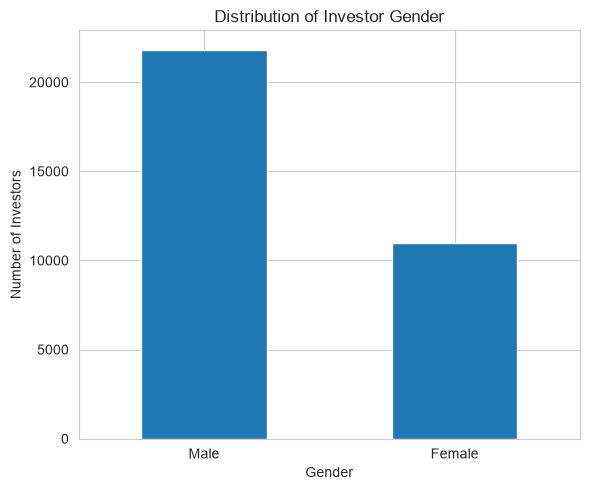

In [20]:
# Distribution of Investor Gender

gender_counts = investor_transactions["gender"].value_counts()

plt.figure(figsize=(6,5))
gender_counts.plot(kind="bar")

plt.title("Distribution of Investor Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Investors")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

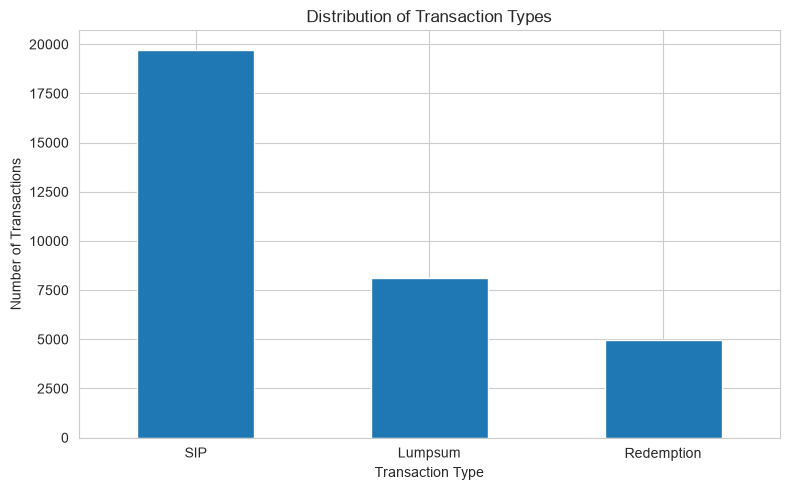

In [21]:
# Distribution of Transaction Types

transaction_counts = investor_transactions["transaction_type"].value_counts()

plt.figure(figsize=(8,5))
transaction_counts.plot(kind="bar")

plt.title("Distribution of Transaction Types")
plt.xlabel("Transaction Type")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [22]:
# Top 10 Schemes by 5-Year Return

top_schemes = (
    scheme_performance
    .sort_values(by="return_5y_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(top_schemes["scheme_name"], top_schemes["return_5y_pct"])

plt.title("Top 10 Mutual Fund Schemes by 5-Year Return")
plt.xlabel("Scheme Name")
plt.ylabel("5-Year Return (%)")

plt.xticks(rotation=75, ha="right")
plt.tight_layout()

plt.show()

KeyError: 'return_5y_pct'

In [23]:
print(scheme_performance.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade', 'expense_ratio_anomaly']


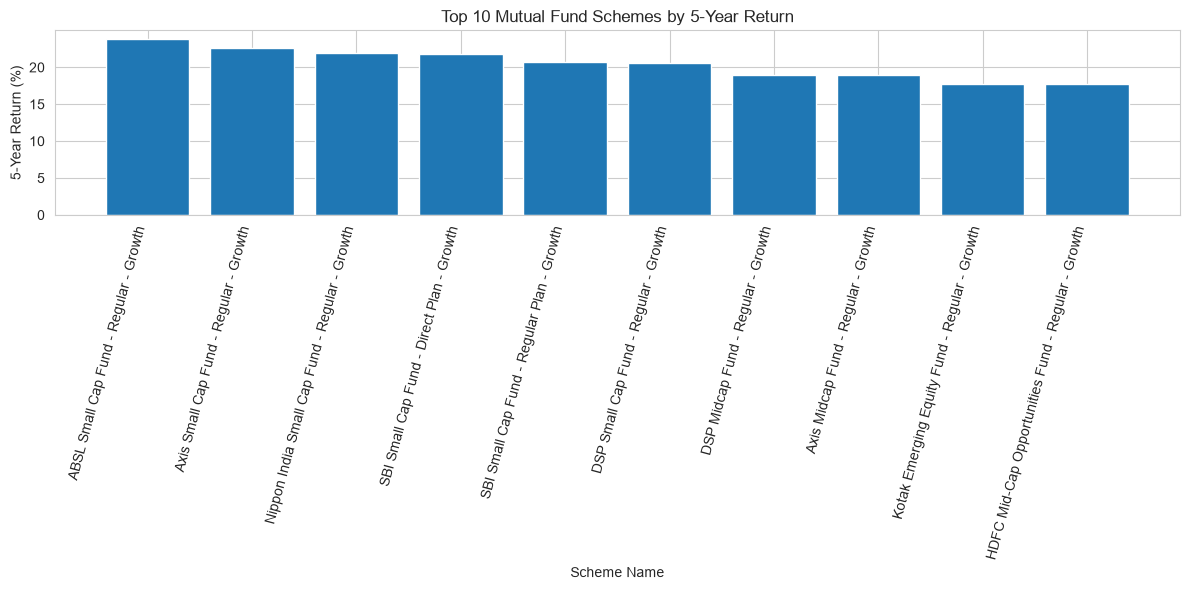

In [24]:
# Top 10 Schemes by 5-Year Return

top_schemes = (
    scheme_performance
    .sort_values(by="return_5yr_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.bar(
    top_schemes["scheme_name"],
    top_schemes["return_5yr_pct"]
)

plt.title("Top 10 Mutual Fund Schemes by 5-Year Return")
plt.xlabel("Scheme Name")
plt.ylabel("5-Year Return (%)")

plt.xticks(rotation=75, ha="right")
plt.tight_layout()

plt.show()

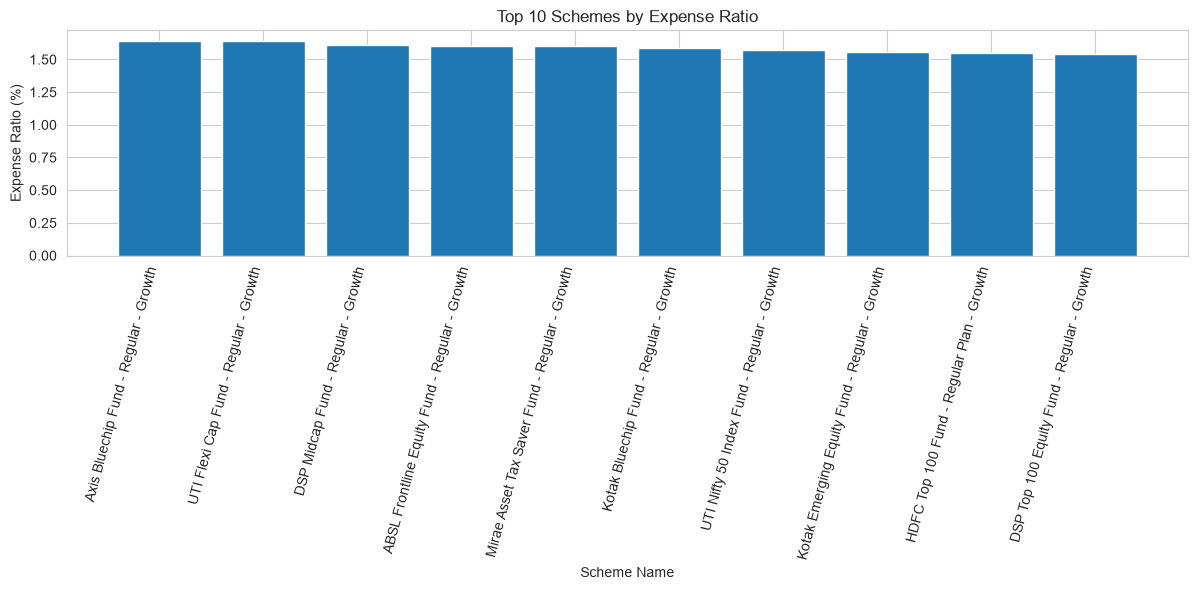

In [25]:
# Top 10 Schemes by Expense Ratio

top_expense = (
    scheme_performance
    .sort_values(by="expense_ratio_pct", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_expense["scheme_name"],
    top_expense["expense_ratio_pct"]
)

plt.title("Top 10 Schemes by Expense Ratio")
plt.xlabel("Scheme Name")
plt.ylabel("Expense Ratio (%)")

plt.xticks(rotation=75, ha="right")
plt.tight_layout()

plt.show()

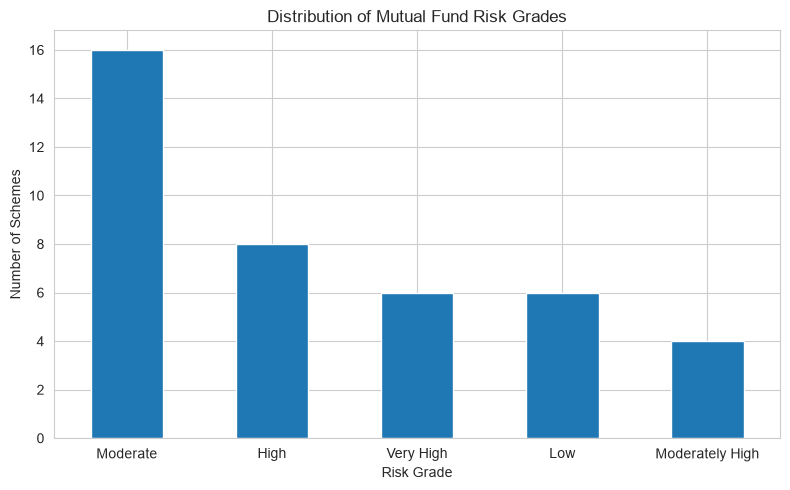

In [26]:
# Distribution of Risk Grades

risk_counts = scheme_performance["risk_grade"].value_counts()

plt.figure(figsize=(8,5))
risk_counts.plot(kind="bar")

plt.title("Distribution of Mutual Fund Risk Grades")
plt.xlabel("Risk Grade")
plt.ylabel("Number of Schemes")

plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

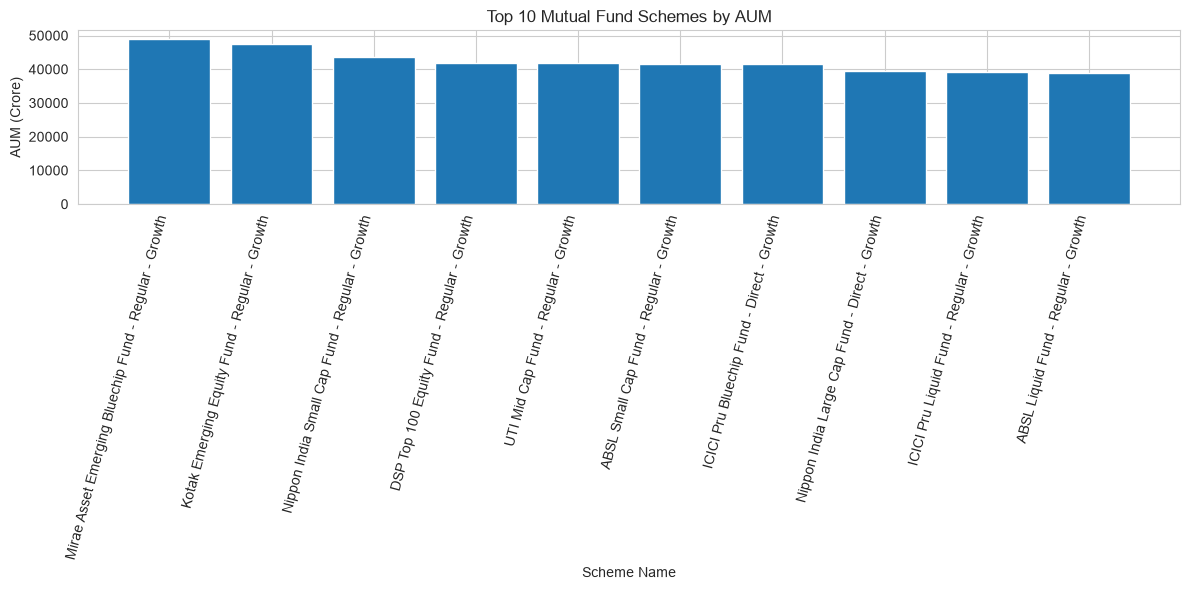

In [27]:
# Top 10 Schemes by AUM

top_aum_schemes = (
    scheme_performance
    .sort_values(by="aum_crore", ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.bar(
    top_aum_schemes["scheme_name"],
    top_aum_schemes["aum_crore"]
)

plt.title("Top 10 Mutual Fund Schemes by AUM")
plt.xlabel("Scheme Name")
plt.ylabel("AUM (Crore)")

plt.xticks(rotation=75, ha="right")
plt.tight_layout()

plt.show()

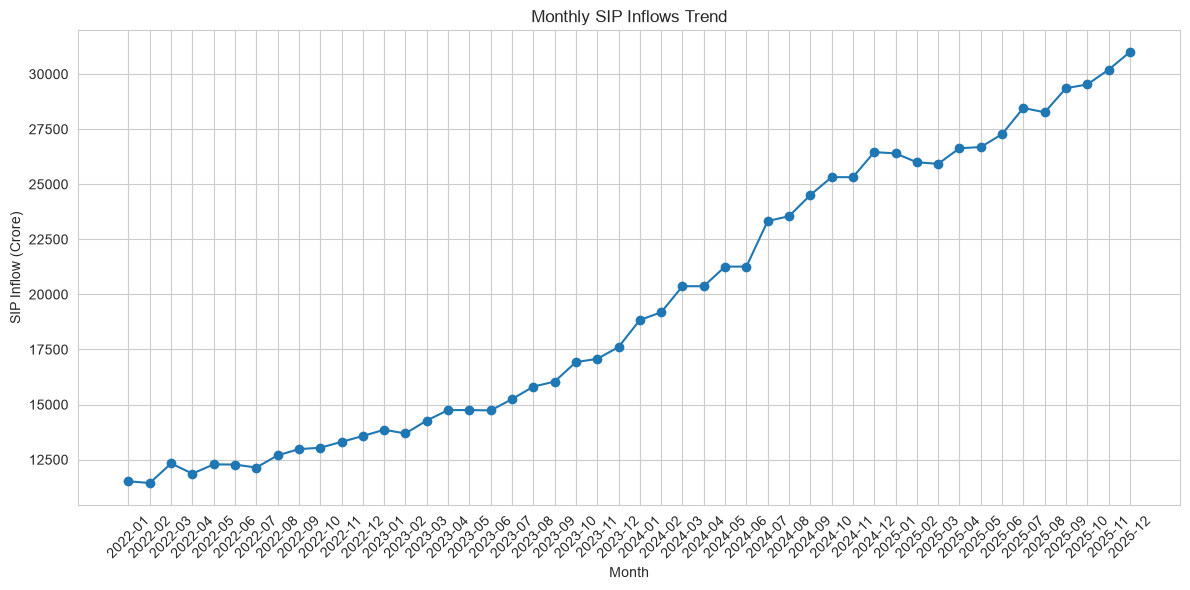

In [28]:
# Monthly SIP Inflows Trend

plt.figure(figsize=(12,6))

plt.plot(
    monthly_sip_inflows["month"],
    monthly_sip_inflows["sip_inflow_crore"],
    marker="o"
)

plt.title("Monthly SIP Inflows Trend")
plt.xlabel("Month")
plt.ylabel("SIP Inflow (Crore)")

plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

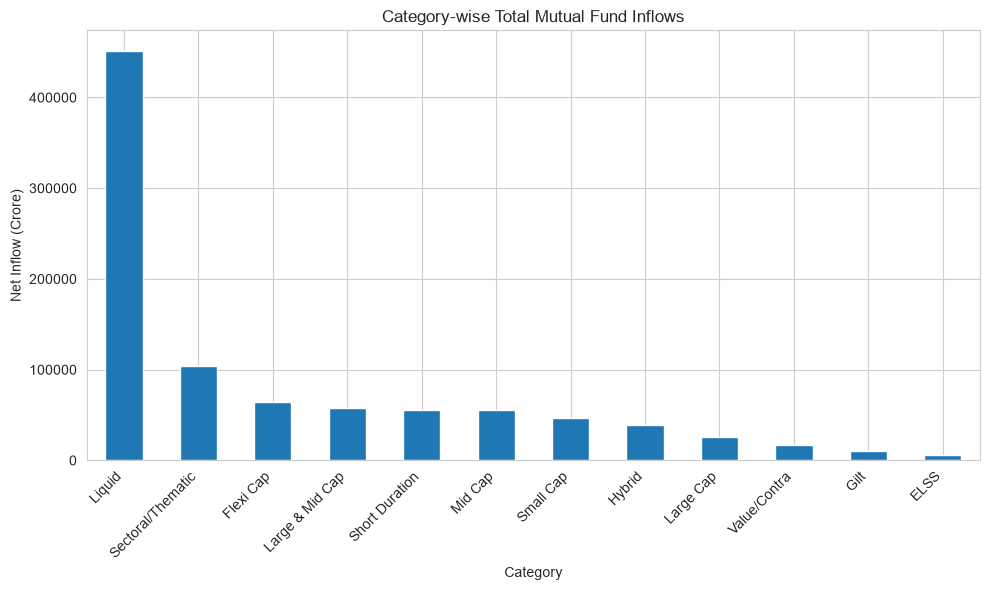

In [29]:
# Category-wise Total Inflows

category_total_inflows = (
    category_inflows
    .groupby("category")["net_inflow_crore"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

category_total_inflows.plot(kind="bar")

plt.title("Category-wise Total Mutual Fund Inflows")
plt.xlabel("Category")
plt.ylabel("Net Inflow (Crore)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [30]:
# Benchmark Index Trend

benchmark_indices["date"] = pd.to_datetime(benchmark_indices["date"])

plt.figure(figsize=(12, 6))

for index_name in benchmark_indices["index_name"].unique():
    index_data = benchmark_indices[
        benchmark_indices["index_name"] == index_name
    ].sort_values("date")

    plt.plot(
        index_data["date"],
        index_data["index_value"],
        label=index_name
    )

plt.title("Benchmark Index Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Index Value")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

KeyError: 'index_value'

<Figure size 1200x600 with 0 Axes>

In [31]:
print(benchmark_indices.columns.tolist())

['date', 'index_name', 'close_value']


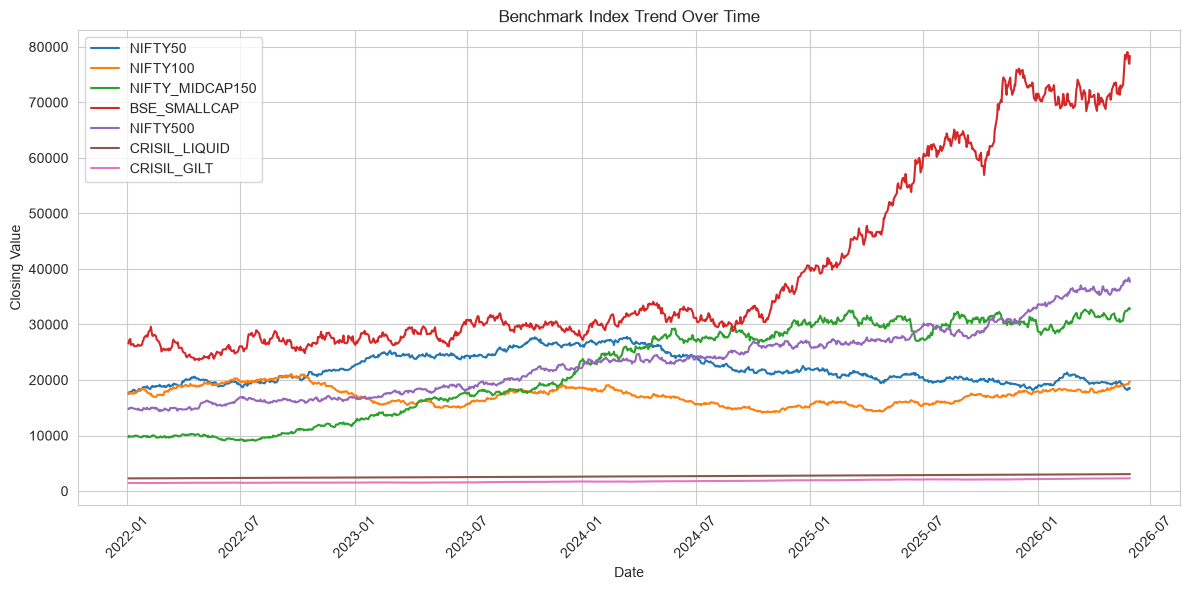

In [32]:
# Benchmark Index Trend

benchmark_indices["date"] = pd.to_datetime(benchmark_indices["date"])

plt.figure(figsize=(12, 6))

for index_name in benchmark_indices["index_name"].unique():
    index_data = (
        benchmark_indices[
            benchmark_indices["index_name"] == index_name
        ]
        .sort_values("date")
    )

    plt.plot(
        index_data["date"],
        index_data["close_value"],
        label=index_name
    )

plt.title("Benchmark Index Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Value")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

# Business Insights

1. Equity mutual funds dominate the market, indicating that most investors prefer equity-based investments over debt funds.

2. A few fund houses manage the highest Assets Under Management (AUM), showing strong investor trust and market leadership.

3. Digital payment methods such as UPI and Net Banking are the most preferred transaction modes among investors.

4. Most investor transactions are completed with KYC verification, reflecting good regulatory compliance.

5. A small number of states contribute a significant share of mutual fund investments, indicating higher investor participation in those regions.

6. Investors in the 26–45 age group form the largest customer segment, making them the primary target audience for fund houses.

7. Purchase and SIP transactions occur more frequently than redemption transactions, indicating long-term investment behavior.

8. Schemes with higher 5-year returns generally attract larger Assets Under Management (AUM), suggesting that historical performance influences investor decisions.

9. Expense ratios vary across schemes, highlighting the importance of cost comparison before investing.

10. Benchmark indices and SIP inflows show long-term growth trends, indicating increasing investor confidence in the mutual fund industry.